# T4D Climate-Response Reset (Fresh Start)

Goal: estimate how *typical estuary water conditions* shift under climate-forcing changes (for example `+1.5 C` air warming), not daily next-step forecasting.

This notebook keeps useful pieces from prior work (data cleaning, atmospheric forcing, baseline deltas) but uses a cleaner scenario-first design.


## Pipeline

1. Load and clean 1-hour collated water+air history.
2. Aggregate to `station x year x month` means with coverage filters.
3. Build station-month baseline climatology and delta targets.
4. Model A: climate deltas -> `delta_water_temp`.
5. Model B: predicted `delta_water_temp` + climate deltas -> `delta_salinity`, `delta_oxygen`, `delta_ph`.
6. Run scenario benchmarks (`+1.5 C` with precip variants).
7. Find historical analogs and compute oxygen-risk summaries.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme( style = 'whitegrid' )
pd.set_option( 'display.max_columns', 200 )

res = 1

In [3]:
# load hourly collated core history
water = pd.read_csv( f'../data/{res}hr/t4d.{res}hr.water.history.csv' )

water = water.rename( columns = {
    'w_temp_c': 'water_temp',
    'w_sal_psu': 'salinity',
    'w_do_mg_l': 'oxygen',
    'w_do_pct': 'oxy_saturation',
    'depth_m': 'depth',
    'w_ph': 'ph',
    'm_wind_ms': 'wind_speed',
    'm_ssrd_kwh_m2': 'solar_radiation',
    'm_precip_mmh': 'precipitation',
    'm_temp_c': 'air_temp',
} )

water[ 'region' ] = water[ 'region' ].astype( str ).str.strip( ).str.lower( )
water[ 'station' ] = water[ 'station' ].astype( str ).str.strip( ).str.lower( )
water = water.loc[ water[ 'region' ] != 'hee' ].copy( )

water[ 'datetime' ] = pd.to_datetime( water[ 'datetime' ], errors = 'coerce' )
water = water.dropna( subset = [ 'datetime' ] )
water[ 'year' ] = water[ 'datetime' ].dt.year
water[ 'month' ] = water[ 'datetime' ].dt.month

# month cyclical encoding
water[ 'month_sin' ] = np.sin( 2 * np.pi * water[ 'month' ] / 12.0 )
water[ 'month_cos' ] = np.cos( 2 * np.pi * water[ 'month' ] / 12.0 )

print( f'rows: { len( water ) }' )
print( f'stations: { water[[ "region", "station" ]].drop_duplicates().shape[ 0 ] }' )


/var/folders/fr/4m_77r353cs6l44l0mrx2cr00000gn/T/ipykernel_95748/3154297872.py:2: DtypeWarning: Columns (0: station) have mixed types. Specify dtype option on import or set low_memory=False.
  water = pd.read_csv( f'../data/{res}hr/t4d.{res}hr.water.history.csv' )


rows: 25074477
stations: 173


In [4]:
# monthly station-year aggregation with minimum hourly coverage
monthly_agg = (
    water
    .groupby( [ 'region', 'station', 'year', 'month' ], as_index = False )
    .agg(
        n_obs = ( 'datetime', 'size' ),
        water_temp = ( 'water_temp', 'mean' ),
        salinity = ( 'salinity', 'mean' ),
        oxygen = ( 'oxygen', 'mean' ),
        ph = ( 'ph', 'mean' ),
        air_temp = ( 'air_temp', 'mean' ),
        precipitation = ( 'precipitation', 'mean' ),
        wind_speed = ( 'wind_speed', 'mean' ),
        solar_radiation = ( 'solar_radiation', 'mean' ),
    )
)

min_obs_per_month = 24 * 7
monthly_agg = monthly_agg.loc[ monthly_agg[ 'n_obs' ] >= min_obs_per_month ].copy( )

monthly_agg[ 'month_sin' ] = np.sin( 2 * np.pi * monthly_agg[ 'month' ] / 12.0 )
monthly_agg[ 'month_cos' ] = np.cos( 2 * np.pi * monthly_agg[ 'month' ] / 12.0 )

print( f'monthly rows after coverage filter: { len( monthly_agg ) }' )
print( monthly_agg[ 'n_obs' ].describe( ).round( 1 ) )


monthly rows after coverage filter: 34476
count    34476.0
mean       727.0
std         41.5
min        168.0
25%        720.0
50%        744.0
75%        744.0
max        744.0
Name: n_obs, dtype: float64


In [5]:
# station-month baseline climatology
baseline_start_year = 1995
baseline_end_year = 2005

baseline_rows = monthly_agg.loc[
    ( monthly_agg[ 'year' ] >= baseline_start_year )
    & ( monthly_agg[ 'year' ] <= baseline_end_year )
].copy( )

baseline_station_month = (
    baseline_rows
    .groupby( [ 'region', 'station', 'month' ], as_index = False )
    .agg(
        water_temp_baseline = ( 'water_temp', 'mean' ),
        salinity_baseline = ( 'salinity', 'mean' ),
        oxygen_baseline = ( 'oxygen', 'mean' ),
        ph_baseline = ( 'ph', 'mean' ),
        air_temp_baseline = ( 'air_temp', 'mean' ),
        precipitation_baseline = ( 'precipitation', 'mean' ),
        wind_speed_baseline = ( 'wind_speed', 'mean' ),
        solar_radiation_baseline = ( 'solar_radiation', 'mean' ),
        n_baseline_months = ( 'year', 'size' ),
    )
)

baseline_station_month = baseline_station_month.loc[ baseline_station_month[ 'n_baseline_months' ] >= 3 ].copy( )

print( f'baseline station-month rows: { len( baseline_station_month ) }' )


baseline station-month rows: 1070


In [6]:
# modeling panel with deltas from station-month baseline
panel = monthly_agg.merge(
    baseline_station_month,
    on = [ 'region', 'station', 'month' ],
    how = 'inner',
)

panel[ 'delta_water_temp' ] = panel[ 'water_temp' ] - panel[ 'water_temp_baseline' ]
panel[ 'delta_salinity' ] = panel[ 'salinity' ] - panel[ 'salinity_baseline' ]
panel[ 'delta_oxygen' ] = panel[ 'oxygen' ] - panel[ 'oxygen_baseline' ]
panel[ 'delta_ph' ] = panel[ 'ph' ] - panel[ 'ph_baseline' ]

panel[ 'delta_air_temp' ] = panel[ 'air_temp' ] - panel[ 'air_temp_baseline' ]
panel[ 'delta_precipitation' ] = panel[ 'precipitation' ] - panel[ 'precipitation_baseline' ]
panel[ 'delta_wind_speed' ] = panel[ 'wind_speed' ] - panel[ 'wind_speed_baseline' ]
panel[ 'delta_solar_radiation' ] = panel[ 'solar_radiation' ] - panel[ 'solar_radiation_baseline' ]

panel = panel.dropna( subset = [
    'delta_water_temp',
    'delta_salinity',
    'delta_oxygen',
    'delta_ph',
    'delta_air_temp',
    'delta_precipitation',
] )

station_keys = panel[ [ 'region', 'station' ] ].drop_duplicates( ).sort_values( [ 'region', 'station' ] ).reset_index( drop = True )
station_keys[ 'holdout_flag' ] = station_keys.index % 5 == 0

panel = panel.merge( station_keys, on = [ 'region', 'station' ], how = 'left' )
panel_train = panel.loc[ ~panel[ 'holdout_flag' ] ].copy( )
panel_holdout = panel.loc[ panel[ 'holdout_flag' ] ].copy( )

print( f'panel rows: { len( panel ) }' )
print( f'train rows: { len( panel_train ) }' )
print( f'holdout rows: { len( panel_holdout ) }' )
print( f'train stations: { panel_train[[ "region", "station" ]].drop_duplicates().shape[ 0 ] }' )
print( f'holdout stations: { panel_holdout[[ "region", "station" ]].drop_duplicates().shape[ 0 ] }' )


panel rows: 17691
train rows: 13828
holdout rows: 3863
train stations: 64
holdout stations: 17


## Model A: Climate -> Delta Water Temp

In [7]:
feature_cols_a = [
    'delta_air_temp',
    'delta_precipitation',
    'delta_wind_speed',
    'delta_solar_radiation',
    'month_sin',
    'month_cos',
    'water_temp_baseline',
]
feature_cols_a = [ col for col in feature_cols_a if col in panel_train.columns ]

target_col_a = 'delta_water_temp'

X_train_a = panel_train[ feature_cols_a ].copy( )
y_train_a = panel_train[ target_col_a ].copy( )

X_holdout_a = panel_holdout[ feature_cols_a ].copy( )
y_holdout_a = panel_holdout[ target_col_a ].copy( )

fill_a = X_train_a.median( numeric_only = True )
X_train_a = X_train_a.fillna( fill_a )
X_holdout_a = X_holdout_a.fillna( fill_a )

model_a_ridge = Ridge( alpha = 1.0 )
model_a_ridge.fit( X_train_a, y_train_a )
pred_a_ridge = model_a_ridge.predict( X_holdout_a )

model_a_hgb = HistGradientBoostingRegressor(
    learning_rate = 0.05,
    max_depth = 4,
    max_iter = 300,
    min_samples_leaf = 20,
    random_state = 42,
)
model_a_hgb.fit( X_train_a, y_train_a )
pred_a_hgb = model_a_hgb.predict( X_holdout_a )

model_a_scores = pd.DataFrame( [
    {
        'model': 'ridge',
        'mae': float( mean_absolute_error( y_holdout_a, pred_a_ridge ) ),
        'rmse': float( mean_squared_error( y_holdout_a, pred_a_ridge ) ** 0.5 ),
        'r2': float( r2_score( y_holdout_a, pred_a_ridge ) ),
    },
    {
        'model': 'hgb',
        'mae': float( mean_absolute_error( y_holdout_a, pred_a_hgb ) ),
        'rmse': float( mean_squared_error( y_holdout_a, pred_a_hgb ) ** 0.5 ),
        'r2': float( r2_score( y_holdout_a, pred_a_hgb ) ),
    },
] ).sort_values( 'rmse' ).reset_index( drop = True )

model_a_best_name = str( model_a_scores.iloc[ 0 ][ 'model' ] )
model_a_best = model_a_hgb if model_a_best_name == 'hgb' else model_a_ridge

print( 'model A holdout scores:' )
display( model_a_scores.round( 4 ) )
print( f'model A selected: { model_a_best_name }' )


model A holdout scores:


,model,mae,rmse,r2
0,hgb,0.6595,0.9589,0.4822
1,ridge,0.7590,1.1319,0.2785


model A selected: hgb


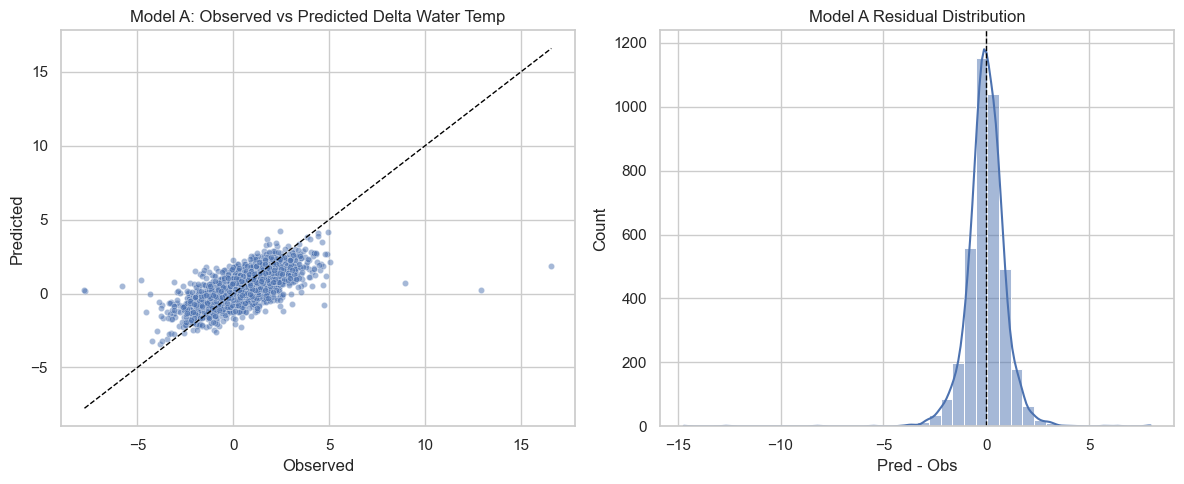

In [8]:
# model A diagnostics
pred_a_best = model_a_best.predict( X_holdout_a )
resid_a = pred_a_best - y_holdout_a

fig, axes = plt.subplots( 1, 2, figsize = ( 12, 5 ) )

sns.scatterplot( x = y_holdout_a, y = pred_a_best, alpha = 0.5, s = 20, ax = axes[ 0 ] )
lo = float( min( y_holdout_a.min( ), pred_a_best.min( ) ) )
hi = float( max( y_holdout_a.max( ), pred_a_best.max( ) ) )
axes[ 0 ].plot( [ lo, hi ], [ lo, hi ], color = 'black', linestyle = '--', linewidth = 1.0 )
axes[ 0 ].set_title( 'Model A: Observed vs Predicted Delta Water Temp' )
axes[ 0 ].set_xlabel( 'Observed' )
axes[ 0 ].set_ylabel( 'Predicted' )

sns.histplot( resid_a, bins = 40, kde = True, ax = axes[ 1 ] )
axes[ 1 ].axvline( 0, color = 'black', linestyle = '--', linewidth = 1.0 )
axes[ 1 ].set_title( 'Model A Residual Distribution' )
axes[ 1 ].set_xlabel( 'Pred - Obs' )

plt.tight_layout( )
plt.show( )


## Model B: Predicted Delta Water Temp + Climate -> Water Property Deltas

In [9]:
# propagate model A predictions into train + holdout for model B
X_all_a = panel[ feature_cols_a ].copy( ).fillna( fill_a )
panel[ 'delta_water_temp_pred' ] = model_a_best.predict( X_all_a )

panel_train = panel.loc[ ~panel[ 'holdout_flag' ] ].copy( )
panel_holdout = panel.loc[ panel[ 'holdout_flag' ] ].copy( )

targets_b = [ 'delta_salinity', 'delta_oxygen', 'delta_ph' ]

feature_cols_b = [
    'delta_water_temp_pred',
    'delta_air_temp',
    'delta_precipitation',
    'delta_wind_speed',
    'delta_solar_radiation',
    'month_sin',
    'month_cos',
    'salinity_baseline',
    'oxygen_baseline',
    'ph_baseline',
]
feature_cols_b = [ col for col in feature_cols_b if col in panel_train.columns ]

model_b_store = { }
model_b_fill_store = { }
scores_b_rows = [ ]
preds_b_rows = [ ]

for target in targets_b:
    train_t = panel_train.dropna( subset = [ target ] ).copy( )
    holdout_t = panel_holdout.dropna( subset = [ target ] ).copy( )

    X_train_t = train_t[ feature_cols_b ].copy( )
    y_train_t = train_t[ target ].copy( )
    X_holdout_t = holdout_t[ feature_cols_b ].copy( )
    y_holdout_t = holdout_t[ target ].copy( )

    fill_t = X_train_t.median( numeric_only = True )
    X_train_t = X_train_t.fillna( fill_t )
    X_holdout_t = X_holdout_t.fillna( fill_t )

    ridge_t = Ridge( alpha = 1.0 )
    ridge_t.fit( X_train_t, y_train_t )
    pred_ridge_t = ridge_t.predict( X_holdout_t )

    hgb_t = HistGradientBoostingRegressor(
        learning_rate = 0.05,
        max_depth = 4,
        max_iter = 300,
        min_samples_leaf = 20,
        random_state = 42,
    )
    hgb_t.fit( X_train_t, y_train_t )
    pred_hgb_t = hgb_t.predict( X_holdout_t )

    score_rows_t = [
        {
            'target': target,
            'model': 'ridge',
            'mae': float( mean_absolute_error( y_holdout_t, pred_ridge_t ) ),
            'rmse': float( mean_squared_error( y_holdout_t, pred_ridge_t ) ** 0.5 ),
            'r2': float( r2_score( y_holdout_t, pred_ridge_t ) ),
            'n_holdout': int( len( y_holdout_t ) ),
        },
        {
            'target': target,
            'model': 'hgb',
            'mae': float( mean_absolute_error( y_holdout_t, pred_hgb_t ) ),
            'rmse': float( mean_squared_error( y_holdout_t, pred_hgb_t ) ** 0.5 ),
            'r2': float( r2_score( y_holdout_t, pred_hgb_t ) ),
            'n_holdout': int( len( y_holdout_t ) ),
        },
    ]

    scores_b_rows.extend( score_rows_t )

    best_name_t = sorted( score_rows_t, key = lambda row: row[ 'rmse' ] )[ 0 ][ 'model' ]
    best_model_t = hgb_t if best_name_t == 'hgb' else ridge_t
    best_pred_t = pred_hgb_t if best_name_t == 'hgb' else pred_ridge_t

    model_b_store[ target ] = best_model_t
    model_b_fill_store[ target ] = fill_t

    pred_frame_t = holdout_t[ [ 'region', 'station', 'year', 'month' ] ].copy( )
    pred_frame_t[ 'target' ] = target
    pred_frame_t[ 'y_true' ] = y_holdout_t.values
    pred_frame_t[ 'y_pred' ] = best_pred_t
    pred_frame_t[ 'residual' ] = pred_frame_t[ 'y_pred' ] - pred_frame_t[ 'y_true' ]
    preds_b_rows.append( pred_frame_t )

scores_b = pd.DataFrame( scores_b_rows ).sort_values( [ 'target', 'rmse' ] ).reset_index( drop = True )
preds_b = pd.concat( preds_b_rows, ignore_index = True )

print( 'model B holdout scores:' )
display( scores_b.round( 4 ) )


model B holdout scores:


,target,model,mae,rmse,r2,n_holdout
0,delta_oxygen,ridge,0.6569,1.1128,0.0788,3863
1,delta_oxygen,hgb,0.6605,1.1175,0.0709,3863
2,delta_ph,ridge,0.1740,0.3924,0.0158,3863
3,delta_ph,hgb,0.1730,0.3928,0.0140,3863
4,delta_salinity,hgb,2.1612,3.1585,0.1199,3863
5,delta_salinity,ridge,2.2379,3.2795,0.0512,3863


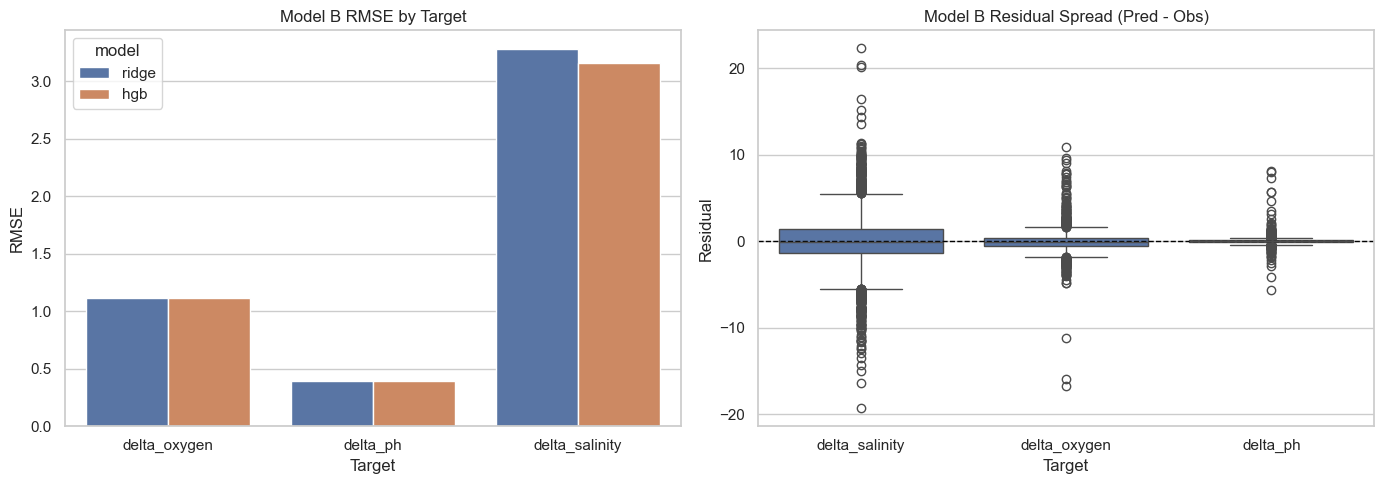

In [10]:
# model B diagnostics plots
fig, axes = plt.subplots( 1, 2, figsize = ( 14, 5 ) )

sns.barplot( data = scores_b, x = 'target', y = 'rmse', hue = 'model', ax = axes[ 0 ] )
axes[ 0 ].set_title( 'Model B RMSE by Target' )
axes[ 0 ].set_xlabel( 'Target' )
axes[ 0 ].set_ylabel( 'RMSE' )

sns.boxplot( data = preds_b, x = 'target', y = 'residual', ax = axes[ 1 ] )
axes[ 1 ].axhline( 0, color = 'black', linestyle = '--', linewidth = 1.0 )
axes[ 1 ].set_title( 'Model B Residual Spread (Pred - Obs)' )
axes[ 1 ].set_xlabel( 'Target' )
axes[ 1 ].set_ylabel( 'Residual' )

plt.tight_layout( )
plt.show( )


## Scenario Benchmarks (`+1.5 C` with precip variants)

In [11]:
# build baseline station-month climatology feature table for scenario projection
scenario_base = baseline_station_month.copy( )
scenario_base[ 'month_sin' ] = np.sin( 2 * np.pi * scenario_base[ 'month' ] / 12.0 )
scenario_base[ 'month_cos' ] = np.cos( 2 * np.pi * scenario_base[ 'month' ] / 12.0 )

scenario_defs = pd.DataFrame( [
    { 'scenario': 'baseline_ref', 'air_temp_add_c': 0.0, 'precip_mult': 1.00 },
    { 'scenario': 'plus1p5C_precip_minus10pct', 'air_temp_add_c': 1.5, 'precip_mult': 0.90 },
    { 'scenario': 'plus1p5C_precip_same', 'air_temp_add_c': 1.5, 'precip_mult': 1.00 },
    { 'scenario': 'plus1p5C_precip_plus10pct', 'air_temp_add_c': 1.5, 'precip_mult': 1.10 },
] )

scenario_rows = [ ]

for _, scen in scenario_defs.iterrows( ):
    d = scenario_base.copy( )
    d[ 'scenario' ] = str( scen[ 'scenario' ] )

    d[ 'delta_air_temp' ] = float( scen[ 'air_temp_add_c' ] )
    d[ 'delta_precipitation' ] = d[ 'precipitation_baseline' ] * ( float( scen[ 'precip_mult' ] ) - 1.0 )
    d[ 'delta_wind_speed' ] = 0.0
    d[ 'delta_solar_radiation' ] = 0.0

    # model A projection
    X_a_proj = d[ feature_cols_a ].copy( )
    X_a_proj = X_a_proj.fillna( fill_a )
    d[ 'delta_water_temp_pred' ] = model_a_best.predict( X_a_proj )

    # model B projections
    for target in targets_b:
        X_b_proj = d[ feature_cols_b ].copy( )
        X_b_proj = X_b_proj.fillna( model_b_fill_store[ target ] )
        d[ f'{ target }_pred' ] = model_b_store[ target ].predict( X_b_proj )

    scenario_rows.append( d )

scenario_pred = pd.concat( scenario_rows, ignore_index = True )

summary_rows = [ ]
for target in targets_b:
    col = f'{ target }_pred'
    g = scenario_pred.groupby( 'scenario', as_index = False )[ col ].mean( )
    g = g.rename( columns = { col: 'mean_pred' } )
    baseline_val = float( g.loc[ g[ 'scenario' ] == 'baseline_ref', 'mean_pred' ].iloc[ 0 ] )
    g[ 'target' ] = target
    g[ 'baseline_mean_pred' ] = baseline_val
    g[ 'delta_vs_baseline' ] = g[ 'mean_pred' ] - baseline_val
    summary_rows.append( g )

scenario_summary = pd.concat( summary_rows, ignore_index = True )
scenario_summary = scenario_summary[ [ 'target', 'scenario', 'mean_pred', 'baseline_mean_pred', 'delta_vs_baseline' ] ]
scenario_summary = scenario_summary.sort_values( [ 'target', 'scenario' ] ).reset_index( drop = True )

print( 'scenario summary (overall):' )
display( scenario_summary.round( 4 ) )


scenario summary (overall):


,target,scenario,mean_pred,baseline_mean_pred,delta_vs_baseline
0,delta_oxygen,baseline_ref,-0.1345,-0.1345,0.0000
1,delta_oxygen,plus1p5C_precip_minus10pct,-0.3970,-0.1345,-0.2625
2,delta_oxygen,plus1p5C_precip_plus10pct,-0.4143,-0.1345,-0.2798
3,delta_oxygen,plus1p5C_precip_same,-0.4053,-0.1345,-0.2708
4,delta_ph,baseline_ref,0.0303,0.0303,0.0000
5,delta_ph,plus1p5C_precip_minus10pct,0.0381,0.0303,0.0078
6,delta_ph,plus1p5C_precip_plus10pct,0.0279,0.0303,-0.0024
7,delta_ph,plus1p5C_precip_same,0.0330,0.0303,0.0027
8,delta_salinity,baseline_ref,0.5755,0.5755,0.0000
9,delta_salinity,plus1p5C_precip_minus10pct,0.9745,0.5755,0.3990


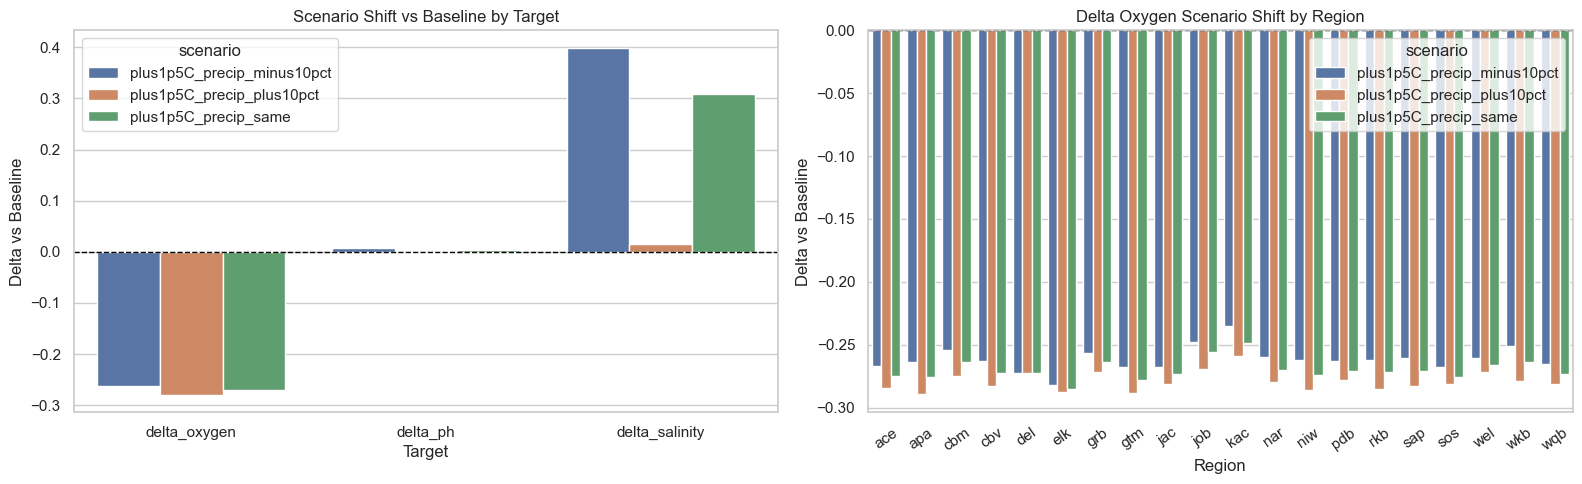

In [12]:
# scenario plots
scenario_plot = scenario_summary.loc[ scenario_summary[ 'scenario' ] != 'baseline_ref' ].copy( )

fig, axes = plt.subplots( 1, 2, figsize = ( 16, 5 ) )

sns.barplot( data = scenario_plot, x = 'target', y = 'delta_vs_baseline', hue = 'scenario', ax = axes[ 0 ] )
axes[ 0 ].axhline( 0, color = 'black', linestyle = '--', linewidth = 1.0 )
axes[ 0 ].set_title( 'Scenario Shift vs Baseline by Target' )
axes[ 0 ].set_xlabel( 'Target' )
axes[ 0 ].set_ylabel( 'Delta vs Baseline' )

scenario_by_region = [ ]
for target in targets_b:
    col = f'{ target }_pred'
    g = scenario_pred.groupby( [ 'scenario', 'region' ], as_index = False )[ col ].mean( )
    g = g.rename( columns = { col: 'mean_pred' } )
    baseline = g.loc[ g[ 'scenario' ] == 'baseline_ref', [ 'region', 'mean_pred' ] ].rename( columns = { 'mean_pred': 'baseline_mean_pred' } )
    g = g.merge( baseline, on = [ 'region' ], how = 'left' )
    g[ 'target' ] = target
    g[ 'delta_vs_baseline' ] = g[ 'mean_pred' ] - g[ 'baseline_mean_pred' ]
    scenario_by_region.append( g )

scenario_by_region = pd.concat( scenario_by_region, ignore_index = True )

oxygen_plot = scenario_by_region.loc[
    ( scenario_by_region[ 'target' ] == 'delta_oxygen' )
    & ( scenario_by_region[ 'scenario' ] != 'baseline_ref' )
].copy( )

sns.barplot( data = oxygen_plot, x = 'region', y = 'delta_vs_baseline', hue = 'scenario', ax = axes[ 1 ] )
axes[ 1 ].axhline( 0, color = 'black', linestyle = '--', linewidth = 1.0 )
axes[ 1 ].set_title( 'Delta Oxygen Scenario Shift by Region' )
axes[ 1 ].set_xlabel( 'Region' )
axes[ 1 ].set_ylabel( 'Delta vs Baseline' )
axes[ 1 ].tick_params( axis = 'x', rotation = 35 )

plt.tight_layout( )
plt.show( )


## Historical Analogs

Find historically similar `station-month` conditions to scenario forcing vectors (`delta_air_temp`, `delta_precipitation`, etc.) as a reality check.


In [13]:
# analog search against historical monthly panel
analog_feature_cols = [ 'delta_air_temp', 'delta_precipitation', 'delta_wind_speed', 'delta_solar_radiation' ]
analog_feature_cols = [ col for col in analog_feature_cols if col in panel.columns ]

hist_analog_space = panel[ [ 'region', 'station', 'year', 'month' ] + analog_feature_cols + [ 'delta_water_temp', 'delta_oxygen', 'delta_salinity', 'delta_ph' ] ].dropna( )

# use +1.5C precip-same as an example analog query set
query = scenario_pred.loc[ scenario_pred[ 'scenario' ] == 'plus1p5C_precip_same' ].copy( )
query = query[ [ 'region', 'station', 'month' ] + analog_feature_cols ].dropna( )

# keep this lightweight: nearest analog per query row in historical space
analog_rows = [ ]
for _, q in query.iterrows( ):
    hist_sub = hist_analog_space.loc[ hist_analog_space[ 'month' ] == q[ 'month' ] ].copy( )
    if len( hist_sub ) == 0:
        continue

    qv = q[ analog_feature_cols ].values.astype( float )
    hv = hist_sub[ analog_feature_cols ].values.astype( float )
    d = np.sqrt( np.sum( np.square( hv - qv ), axis = 1 ) )

    best_idx = int( np.argmin( d ) )
    row = hist_sub.iloc[ best_idx ]

    analog_rows.append( {
        'query_region': q[ 'region' ],
        'query_station': q[ 'station' ],
        'month': int( q[ 'month' ] ),
        'analog_region': row[ 'region' ],
        'analog_station': row[ 'station' ],
        'analog_year': int( row[ 'year' ] ),
        'distance': float( d[ best_idx ] ),
        'analog_delta_water_temp': float( row[ 'delta_water_temp' ] ),
        'analog_delta_oxygen': float( row[ 'delta_oxygen' ] ),
        'analog_delta_salinity': float( row[ 'delta_salinity' ] ),
        'analog_delta_ph': float( row[ 'delta_ph' ] ),
    } )

analog_table = pd.DataFrame( analog_rows ).sort_values( 'distance' ).reset_index( drop = True )

print( 'top analogs (closest forcing matches):' )
display( analog_table.head( 25 ).round( 4 ) )


top analogs (closest forcing matches):


,query_region,query_station,month,analog_region,analog_station,analog_year,distance,analog_delta_water_temp,analog_delta_oxygen,analog_delta_salinity,analog_delta_ph
0,elk,ap,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
1,elk,sm,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
2,wel,in,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
3,rkb,fb,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
4,elk,vm,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
5,pdb,jl,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
6,wel,lm,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
7,apa,db,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
8,grb,gb,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058
9,pdb,gs,12,apa,cp,2024,0.0116,1.4718,-0.9089,8.1528,-0.2058


## Oxygen Risk Snapshot

Project absolute oxygen under each scenario and compute the share of `station-month` rows below risk thresholds.


oxygen risk summary:


,scenario,region,n_rows,frac_below,mean_oxygen_projected,threshold_mg_l
0,baseline_ref,ace,60,0.0000,6.2565,2.0
1,plus1p5C_precip_minus10pct,ace,60,0.0000,5.9949,2.0
2,plus1p5C_precip_plus10pct,ace,60,0.0000,5.9722,2.0
3,plus1p5C_precip_same,ace,60,0.0000,5.9841,2.0
4,baseline_ref,apa,48,0.0000,7.2455,2.0
...,...,...,...,...,...,...
235,plus1p5C_precip_same,wkb,39,0.1538,6.7791,5.0
236,baseline_ref,wqb,59,0.0339,8.8864,5.0
237,plus1p5C_precip_minus10pct,wqb,59,0.0339,8.6261,5.0
238,plus1p5C_precip_plus10pct,wqb,59,0.0339,8.6065,5.0


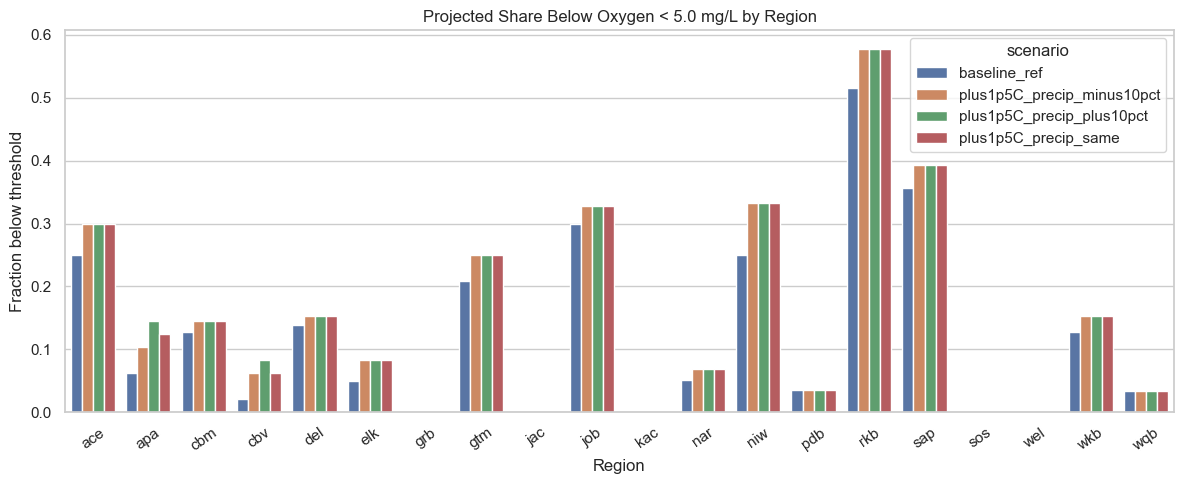

In [15]:
oxygen_thresholds = [ 5.0, 4.0, 2.0 ]

oxygen_rows = scenario_pred[ [ 'scenario', 'region', 'station', 'month', 'oxygen_baseline', 'delta_oxygen_pred' ] ].copy( )
oxygen_rows[ 'oxygen_projected' ] = oxygen_rows[ 'oxygen_baseline' ] + oxygen_rows[ 'delta_oxygen_pred' ]

risk_rows = [ ]
for thr in oxygen_thresholds:
    tmp = (
        oxygen_rows
        .groupby( [ 'scenario', 'region' ], as_index = False )
        .agg(
            n_rows = ( 'oxygen_projected', 'size' ),
            frac_below = ( 'oxygen_projected', lambda s: float( ( s < thr ).mean( ) ) ),
            mean_oxygen_projected = ( 'oxygen_projected', 'mean' ),
        )
    )
    tmp[ 'threshold_mg_l' ] = thr
    risk_rows.append( tmp )

oxygen_risk = pd.concat( risk_rows, ignore_index = True )
oxygen_risk = oxygen_risk.sort_values( [ 'threshold_mg_l', 'region', 'scenario' ] ).reset_index( drop = True )

print( 'oxygen risk summary:' )
display( oxygen_risk.round( 4 ) )

plt.figure( figsize = ( 12, 5 ) )
plot_df = oxygen_risk.loc[ oxygen_risk[ 'threshold_mg_l' ] == 5.0 ].copy( )
sns.barplot( data = plot_df, x = 'region', y = 'frac_below', hue = 'scenario' )
plt.title( 'Projected Share Below Oxygen < 5.0 mg/L by Region' )
plt.xlabel( 'Region' )
plt.ylabel( 'Fraction below threshold' )
plt.xticks( rotation = 35 )
plt.tight_layout( )
plt.show( )


In [ ]:
# optional exports for writeup handoff
scenario_summary.to_csv( '../data/reference/t4d.reset.phase7.scenario.summary.csv', index = False )
scenario_by_region.to_csv( '../data/reference/t4d.reset.phase7.scenario.by_region.csv', index = False )
oxygen_risk.to_csv( '../data/reference/t4d.reset.phase7.oxygen.risk.csv', index = False )

print( 'saved:' )
print( '  ../data/reference/t4d.reset.phase7.scenario.summary.csv' )
print( '  ../data/reference/t4d.reset.phase7.scenario.by_region.csv' )
print( '  ../data/reference/t4d.reset.phase7.oxygen.risk.csv' )
